In [7]:
!pip install sqlalchemy psycopg2 pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine

In [ ]:
import os

os.environ['DB_USER'] = 'postgres'
os.environ['DB_PASSWORD'] = 'xxxxxxxx'
os.environ['DB_HOST'] = 'localhost'
os.environ['DB_PORT'] = '5432'
os.environ['DB_NAME'] = 'world'

In [3]:
# Define your connection string
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Test the connection
with engine.connect() as connection:
    print("Connected successfully!")

Connected successfully!


In [4]:
query = """
SELECT
c.name as country_name,
count(1) AS number_of_official_languages
FROM country c
INNER JOIN countrylanguage cl
ON c.code = cl.countrycode
WHERE cl.isofficial = 'T'
GROUP BY c.name
HAVING count(1) >2
ORDER BY number_of_official_languages DESC, country_name;
"""
df = pd.read_sql(query, engine)

In [7]:
df

,country_name,number_of_official_languages
0,South Africa ...,4
1,Switzerland ...,4
2,Belgium ...,3
3,Bolivia ...,3
4,Luxembourg ...,3
5,Peru ...,3
6,Singapore ...,3
7,Vanuatu ...,3


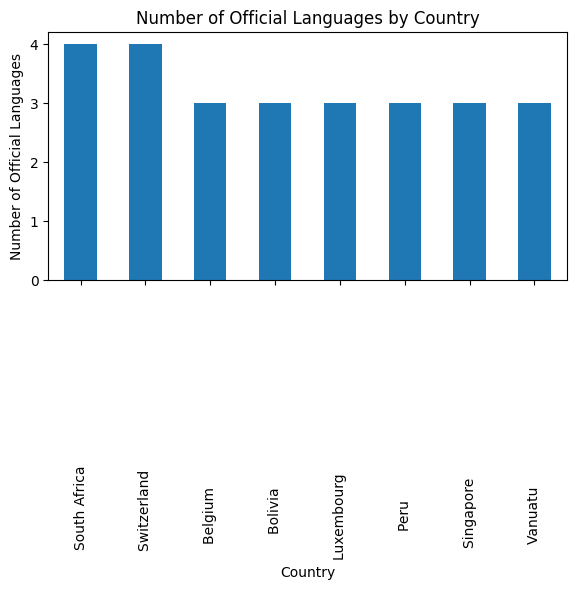

In [ ]:
df.set_index('country_name')['number_of_official_languages'].plot(
    kind='bar', figsize=(6, 6)
)
plt.title('Number of Official Languages by Country')
plt.xlabel('Country')
plt.ylabel('Number of Official Languages')
plt.tight_layout()
plt.show()